04 · Uncertainty - FOSM (Schur) + forecast validation (3-layer pilot points)

First-order second-moment (FOSM / Schur) uncertainty from the GLM Jacobian and the prior covariance.

1. Imports

In [21]:
from pathlib import Path
import numpy as np, pandas as pd
import pyemu
from pyemu import plot_utils
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from helper_fb3_04_v1 import (forecast_table, to_summary_df, param_reduction_by_group,
                              load_truth_forecasts)

2. Paths

In [22]:
from paths import PEST_TEMPLATE as TEMPLATE, PEST_MASTER as MASTER, FORECASTS_CSV as TRUTH_FORECASTS
CASE = "freyberg_3l"

3. Load control file, Jacobian, prior covariance

In [23]:
pst = pyemu.Pst(str(MASTER / f"{CASE}.pst"))
jco = str(MASTER / f"{CASE}.jcb")
prior_cov = pyemu.Cov.from_binary(str(TEMPLATE / "prior_cov.jcb"))
print("forecasts:", pst.pestpp_options.get("forecasts"), "| prior cov:", prior_cov.shape)

forecasts: tailwater_sp13,headwater_sp22,gw_3_sp22 | prior cov: (228, 228)


4. Build the Schur (FOSM) object

The prior covariance is rebuilt symmetric and subset to the adjustable parameters (the 1-layer
lesson); the Jacobian already contains the forecast rows, so they are not passed again.

In [24]:
prior_cov = pyemu.Cov.from_parameter_data(pst)
prior_cov = prior_cov.get(pst.adj_par_names, pst.adj_par_names)
la = pyemu.Schur(jco=jco, pst=pst, parcov=prior_cov)
print("forecasts tracked:", list(la.forecast_names))

forecasts tracked: ['tailwater_sp13', 'headwater_sp22', 'gw_3_sp22']


5. Forecast uncertainty: prior vs posterior (table)

In [25]:
fs = forecast_table(la)
fs

,prior_std,post_std,percent_reduction
tailwater_sp13,221.791064,116.651267,47.404884
headwater_sp22,261.999981,226.960599,13.373811
gw_3_sp22,0.411410,0.293479,28.665148


**Reading it:** large `percent_reduction` = the history strongly informs that forecast;
small = the forecast stays uncertain after calibration (data-limited).

6. Forecast distributions (prior vs posterior) with truth overlay

In [ ]:
# pyemu utils ver

res = pst.res.set_index("name")
fmeans = res.loc[la.forecast_names, "modelled"]                  # calibrated forecast means
fdf = to_summary_df(la.get_forecast_summary(), fmeans)
truth_fore = load_truth_forecasts(TRUTH_FORECASTS, list(la.forecast_names))   # truth (validation only)

ret = plot_utils.plot_summary_distributions(fdf, label_post=True, subplots=True)
axs = []

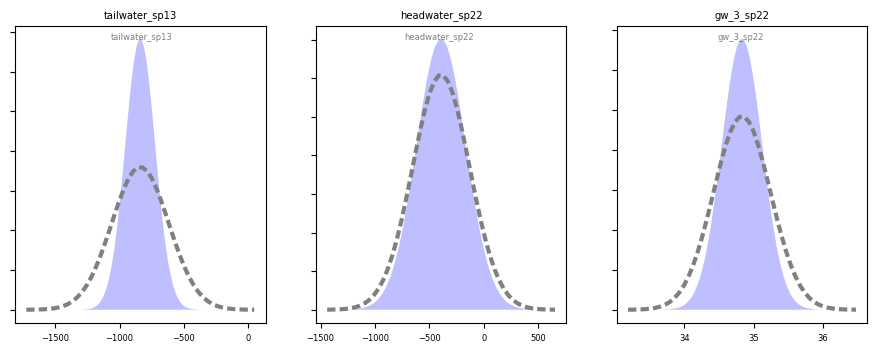

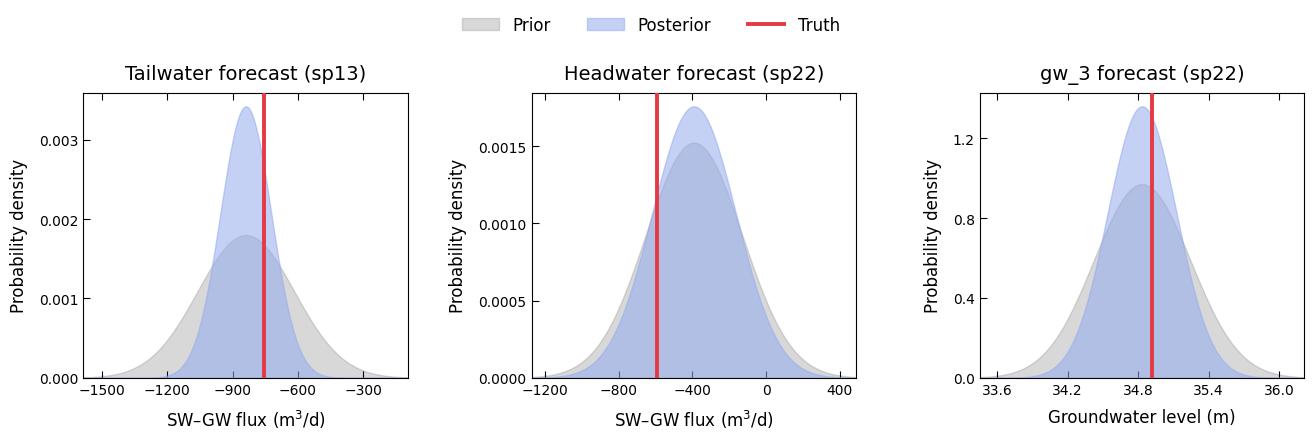

In [27]:
forecast_meta = {
    "tailwater_sp13": (
        "Tailwater forecast (sp13)",
        r"SW–GW flux (m$^3$/d)"
    ),
    "headwater_sp22": (
        "Headwater forecast (sp22)",
        r"SW–GW flux (m$^3$/d)"
    ),
    "gw_3_sp22": (
        "gw_3 forecast (sp22)",
        "Groundwater level (m)"
    ),
}

prior_color = "0.60"          # gray
posterior_color = "#94ACEE"   # pale blue
truth_color = "#E53945"       # red

def gaussian_pdf(x, mean, stdev):
    return np.exp(-0.5 * ((x - mean) / stdev) ** 2) / (
        stdev * np.sqrt(2.0 * np.pi)
    )

fig, axes = plt.subplots(
    1, 3,
    figsize=(13.2, 4.6),
    gridspec_kw={"wspace": 0.38}
)

for i, (ax, nm) in enumerate(zip(axes, fdf.index)):

    row = fdf.loc[nm]

    prior_mean = float(row.get("prior_mean", fmeans[nm]))
    post_mean = float(row.get("post_mean", fmeans[nm]))

    prior_std = (
        float(row["prior_stdev"])
        if "prior_stdev" in fdf.columns
        else np.sqrt(float(row["prior_var"]))
    )

    post_std = (
        float(row["post_stdev"])
        if "post_stdev" in fdf.columns
        else np.sqrt(float(row["post_var"]))
    )

    truth = float(truth_fore[nm])

    lo = min(
        prior_mean - 3 * prior_std,
        post_mean - 3 * post_std,
        truth
    )

    hi = max(
        prior_mean + 3 * prior_std,
        post_mean + 3 * post_std,
        truth
    )

    pad = 0.06 * (hi - lo)
    x = np.linspace(lo - pad, hi + pad, 500)

    y_prior = gaussian_pdf(x, prior_mean, prior_std)
    y_post = gaussian_pdf(x, post_mean, post_std)

    ax.fill_between(
        x, 0, y_prior,
        color=prior_color,
        alpha=0.38,
        label="Prior" if i == 0 else "_nolegend_",
        zorder=1
    )

    ax.fill_between(
        x, 0, y_post,
        color=posterior_color,
        alpha=0.55,
        label="Posterior" if i == 0 else "_nolegend_",
        zorder=2
    )

    ax.axvline(
        truth,
        color=truth_color,
        lw=2.8,
        label="Truth" if i == 0 else "_nolegend_",
        zorder=3
    )

    title, xlabel = forecast_meta[nm]

    ax.set_title(title, fontsize=14, pad=10)
    ax.set_xlabel(xlabel, fontsize=12, labelpad=8)
    ax.set_ylabel("Probability density", fontsize=12, labelpad=8)

    ax.set_xlim(x[0], x[-1])
    ax.set_ylim(bottom=0)

    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4))

    ax.tick_params(
        axis="both",
        labelsize=10,
        top=True,
        direction="in",
        length=5
    )

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=3,
    frameon=False,
    fontsize=12,
    handlelength=2.2,
    columnspacing=2.2
)

fig.subplots_adjust(
    left=0.07,
    right=0.995,
    bottom=0.20,
    top=0.82
)

plt.show()

7. Forecast uncertainty reduction (bar)

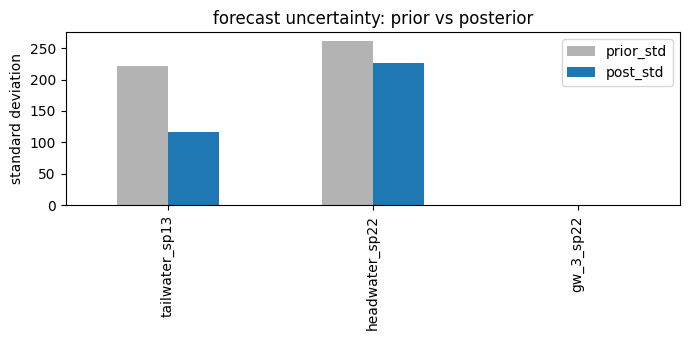

In [28]:
fs[["prior_std", "post_std"]].plot.bar(figsize=(7, 3.5), color=["0.7", "tab:blue"])
plt.ylabel("standard deviation"); plt.title("forecast uncertainty: prior vs posterior")
plt.tight_layout(); plt.show()

8. Parameter uncertainty reduction by group

In [29]:
pg = param_reduction_by_group(la)
pg.sort_values("percent_reduction", ascending=False)

,prior_std,post_std,percent_reduction
group,,,
hk_l3_i:33_j:9,0.5,0.365320,26.935972
hk_l1_i:15_j:9,0.5,0.421276,15.744823
hk_l3_i:9_j:9,0.5,0.423470,15.306096
hk_l3_i:3_j:9,0.5,0.432023,13.595474
hk_l3_i:3_j:15,0.5,0.432254,13.549237
...,...,...,...
ss_l2_i:3_j:15,0.5,0.500000,0.000003
ss_l1_i:15_j:3,0.5,0.500000,0.000003
ss_l1_i:21_j:15,0.5,0.500000,0.000003


9. Identifiability (pyEMU ErrVar) - which parameters the data informs

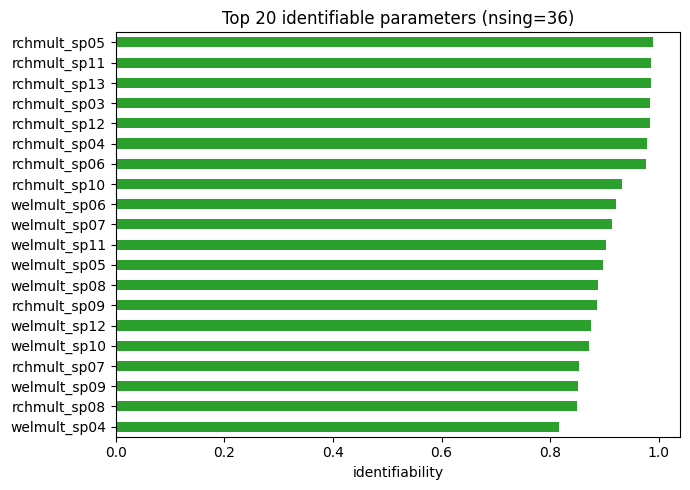

mean identifiability: 0.1579 | max: 0.9896


In [30]:
ev = pyemu.ErrVar(jco=jco, pst=pst, parcov=prior_cov)
nsing = pst.nnz_obs        # 유효 정보 차원 ~ 관측 수(36)로 truncation
idf = ev.get_identifiability_dataframe(singular_value=nsing)
idf["ident"].sort_values(ascending=False).head(20).plot.barh(figsize=(7,5), color="tab:green")
plt.xlabel("identifiability"); plt.title(f"Top 20 identifiable parameters (nsing={nsing})")
plt.gca().invert_yaxis(); plt.tight_layout(); plt.show()
print("mean identifiability:", round(float(idf['ident'].mean()),4), "| max:", round(float(idf['ident'].max()),4))

10. Forecast validation: calibrated vs truth (truth used here only)

In [31]:
val = pd.DataFrame({
    "calibrated": res.loc[la.forecast_names, "modelled"],
    "truth": truth_fore,
    "prior_std": fs["prior_std"], "post_std": fs["post_std"],
})
val["within_2sigma"] = (np.abs(val["calibrated"] - val["truth"]) <= 2 * val["post_std"])
from paths import TABLES_DIR as TABLES; TABLES.mkdir(parents=True, exist_ok=True)
val.to_csv(TABLES / "forecast_validation.csv")
val

,calibrated,truth,prior_std,post_std,within_2sigma
tailwater_sp13,-838.936404,-754.290845,221.791064,116.651267,True
headwater_sp22,-391.299599,-590.775973,261.999981,226.960599,True
gw_3_sp22,34.833689,34.921403,0.411410,0.293479,True
